In [1]:
import pandas as pd

itaipu = pd.read_csv('Dados/ITAIPU_mensal.csv')
itaipu = itaipu.rename(columns={
    'ano_mes': 'year_month',
    'geracao_media_MW': 'avg_generation_MW',
    'geracao_total_MWh': 'total_generation_MWh',
    'geracao_min_MW': 'min_generation_MW',
    'geracao_max_MW': 'max_generation_MW',
    'horas_registradas': 'hours_recorded',
    'linhas_suspeitas': 'suspect_rows'
})
itaipu['year_month'] = pd.to_datetime(itaipu['year_month'])
print(itaipu.head())

  year_month  avg_generation_MW  total_generation_MWh  min_generation_MW  \
0 2000-01-01        9518.173522             7081521.1             6055.9   
1 2000-02-01        9814.524282             6830908.9             6883.4   
2 2000-03-01       10910.862231             8117681.5             8007.0   
3 2000-04-01       10558.610556             7602199.6             6002.9   
4 2000-05-01        9759.788306             7261282.5             6871.2   

   max_generation_MW  hours_recorded  suspect_rows  
0            11639.3             744             6  
1            11946.6             696             1  
2            12334.4             744             0  
3            12879.0             720             0  
4            12710.5             744             1  


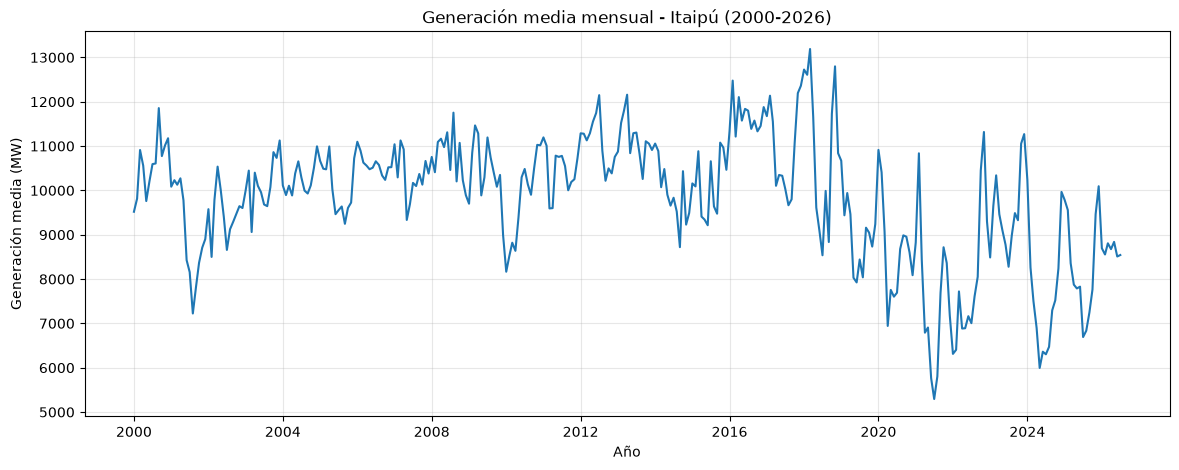

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(itaipu['year_month'], itaipu['avg_generation_MW'])
plt.title('Generación media mensual - Itaipú (2000-2026)')
plt.xlabel('Año')
plt.ylabel('Generación media (MW)')
plt.grid(alpha=0.3)
plt.show()

<Figure size 1000x500 with 0 Axes>

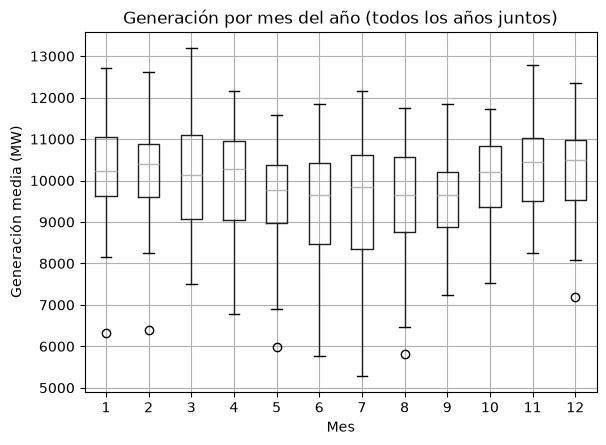

In [3]:
itaipu['month'] = itaipu['year_month'].dt.month

plt.figure(figsize=(10,5))
itaipu.boxplot(column='avg_generation_MW', by='month')
plt.title('Generación por mes del año (todos los años juntos)')
plt.suptitle('')
plt.xlabel('Mes')
plt.ylabel('Generación media (MW)')
plt.show()

In [4]:
rainfall = pd.read_csv('Dados/CHUVA_Encarnacion_mensal.csv')
oni = pd.read_csv('Dados/ONI_mensal.csv')

rainfall = rainfall.rename(columns={'ano_mes':'year_month','ano':'year','mes':'month','chuva_mm':'rainfall_mm'})
oni = oni.rename(columns={'ano_mes':'year_month','ano':'year','mes':'month','fase':'phase'})

rainfall['year_month'] = pd.to_datetime(rainfall['year_month'])
oni['year_month'] = pd.to_datetime(oni['year_month'])

print(rainfall.head())
print(oni.head())


  year_month  year  month  rainfall_mm
0 1990-01-01  1990      1        224.9
1 1990-02-01  1990      2         84.3
2 1990-03-01  1990      3        142.6
3 1990-04-01  1990      4        373.4
4 1990-05-01  1990      5        134.0
  year_month  year  month  ONI   phase
0 1990-01-01  1990      1  0.1  Neutro
1 1990-02-01  1990      2  0.2  Neutro
2 1990-03-01  1990      3  0.3  Neutro
3 1990-04-01  1990      4  0.3  Neutro
4 1990-05-01  1990      5  0.3  Neutro


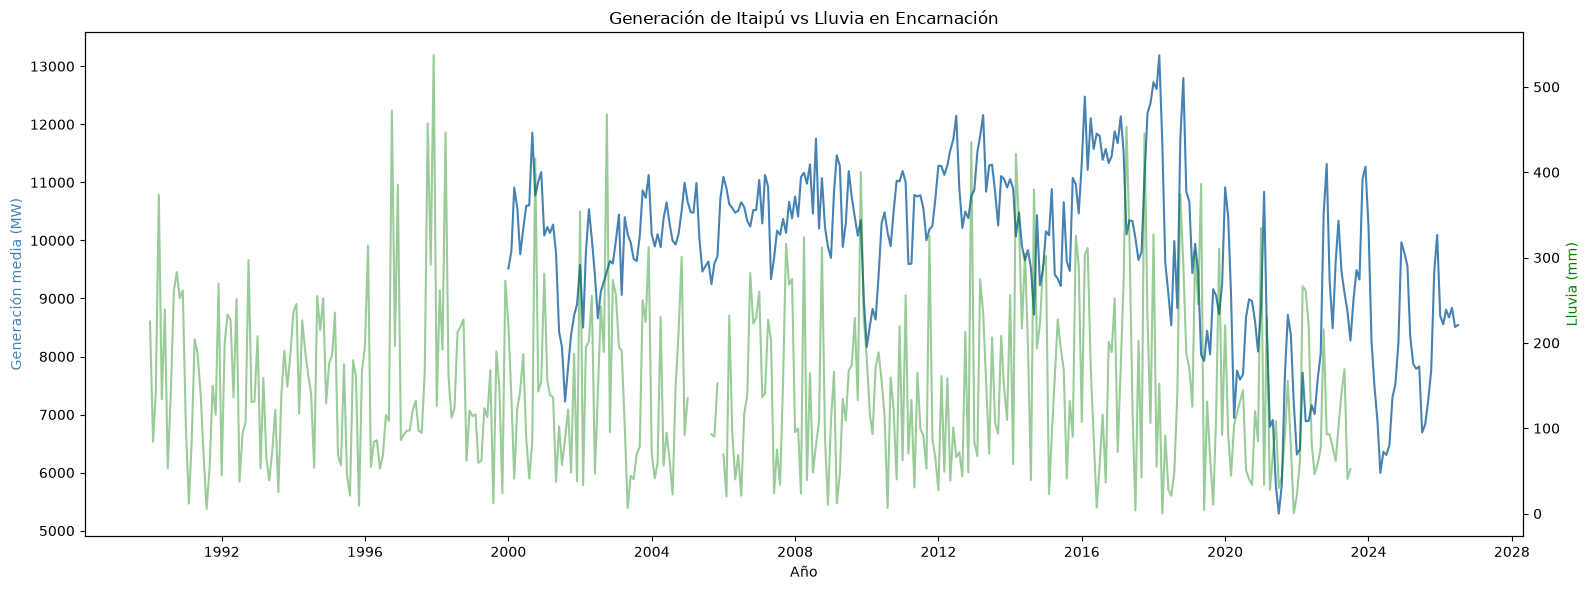

In [5]:
fig, ax1 = plt.subplots(figsize=(16,6))

ax1.plot(itaipu['year_month'], itaipu['avg_generation_MW'], color='steelblue', label='Generación Itaipú (MW)')
ax1.set_ylabel('Generación media (MW)', color='steelblue')
ax1.set_xlabel('Año')

ax2 = ax1.twinx()
ax2.plot(rainfall['year_month'], rainfall['rainfall_mm'], color='green', alpha=0.4, label='Lluvia Encarnación (mm)')
ax2.set_ylabel('Lluvia (mm)', color='green')

plt.title('Generación de Itaipú vs Lluvia en Encarnación')
fig.tight_layout()
plt.show()

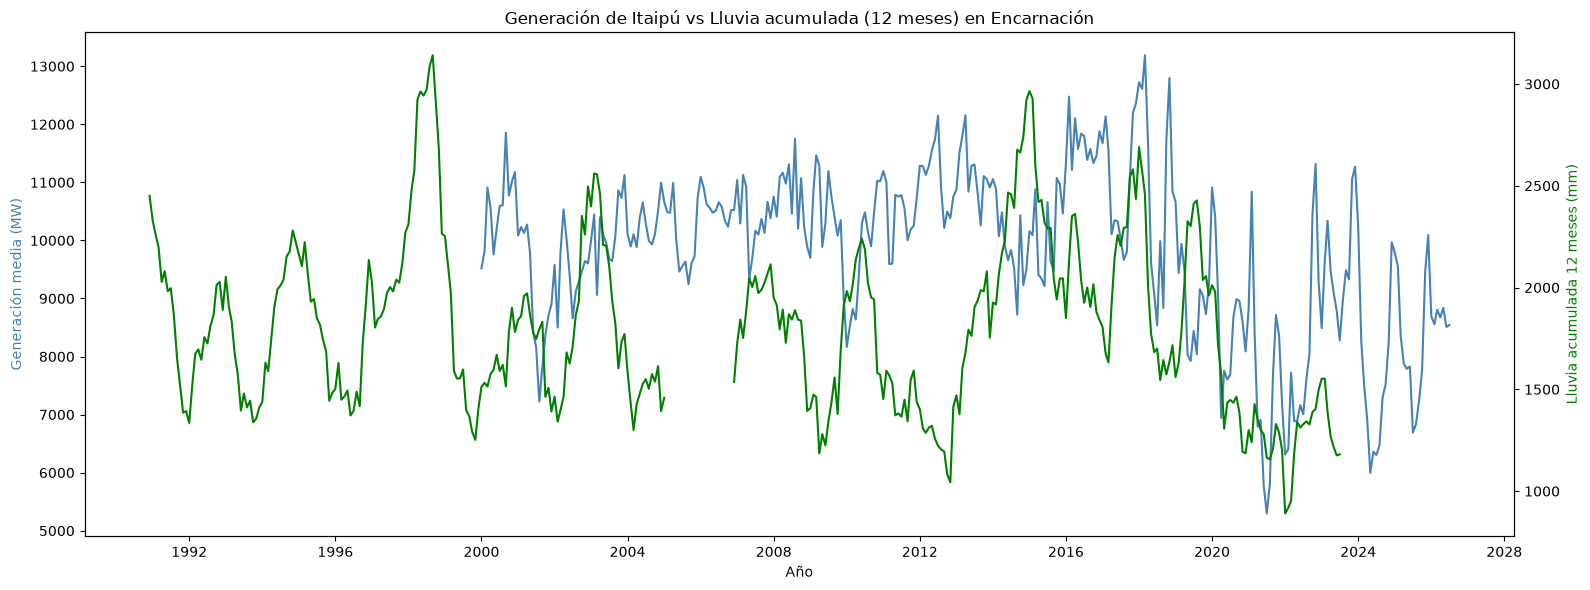

In [6]:
rainfall['rainfall_12m'] = rainfall['rainfall_mm'].rolling(window=12).sum()

fig, ax1 = plt.subplots(figsize=(16,6))

ax1.plot(itaipu['year_month'], itaipu['avg_generation_MW'], color='steelblue', label='Generación Itaipú (MW)')
ax1.set_ylabel('Generación media (MW)', color='steelblue')
ax1.set_xlabel('Año')

ax2 = ax1.twinx()
ax2.plot(rainfall['year_month'], rainfall['rainfall_12m'], color='green', label='Lluvia acumulada 12m (mm)')
ax2.set_ylabel('Lluvia acumulada 12 meses (mm)', color='green')

plt.title('Generación de Itaipú vs Lluvia acumulada (12 meses) en Encarnación')
fig.tight_layout()
plt.show()

In [7]:
merged = itaipu[['year_month','avg_generation_MW']].merge(
    rainfall[['year_month','rainfall_12m']], on='year_month', how='inner'
).dropna()

correlation = merged['avg_generation_MW'].corr(merged['rainfall_12m'])
print(f"Correlação (mesmo mês): {correlation:.3f}")

Correlação (mesmo mês): 0.243


In [8]:
print("Correlação da geração com a chuva acumulada, testando diferentes atrasos:\n")

for lag in range(0, 13):
    shifted = rainfall[['year_month','rainfall_12m']].copy()
    shifted['year_month'] = shifted['year_month'] + pd.DateOffset(months=lag)
    
    test = itaipu[['year_month','avg_generation_MW']].merge(
        shifted, on='year_month', how='inner'
    ).dropna()
    
    corr = test['avg_generation_MW'].corr(test['rainfall_12m'])
    print(f"Atraso de {lag:2d} meses -> correlação: {corr:.3f}")

Correlação da geração com a chuva acumulada, testando diferentes atrasos:

Atraso de  0 meses -> correlação: 0.243
Atraso de  1 meses -> correlação: 0.251
Atraso de  2 meses -> correlação: 0.243
Atraso de  3 meses -> correlação: 0.227
Atraso de  4 meses -> correlação: 0.234
Atraso de  5 meses -> correlação: 0.236
Atraso de  6 meses -> correlação: 0.246
Atraso de  7 meses -> correlação: 0.243
Atraso de  8 meses -> correlação: 0.247
Atraso de  9 meses -> correlação: 0.252
Atraso de 10 meses -> correlação: 0.249
Atraso de 11 meses -> correlação: 0.248
Atraso de 12 meses -> correlação: 0.257


In [9]:
print("Correlación entre generación y ONI, probando diferentes retrasos:\n")

for lag in range(0, 13):
    shifted = oni[['year_month','ONI']].copy()
    shifted['year_month'] = shifted['year_month'] + pd.DateOffset(months=lag)
    
    test = itaipu[['year_month','avg_generation_MW']].merge(
        shifted, on='year_month', how='inner'
    ).dropna()
    
    corr = test['avg_generation_MW'].corr(test['ONI'])
    print(f"Retraso de {lag:2d} meses -> correlación: {corr:.3f}")

Correlación entre generación y ONI, probando diferentes retrasos:

Retraso de  0 meses -> correlación: 0.009
Retraso de  1 meses -> correlación: -0.020
Retraso de  2 meses -> correlación: -0.039
Retraso de  3 meses -> correlación: -0.049
Retraso de  4 meses -> correlación: -0.048
Retraso de  5 meses -> correlación: -0.040
Retraso de  6 meses -> correlación: -0.027
Retraso de  7 meses -> correlación: -0.011
Retraso de  8 meses -> correlación: 0.006
Retraso de  9 meses -> correlación: 0.021
Retraso de 10 meses -> correlación: 0.029
Retraso de 11 meses -> correlación: 0.028
Retraso de 12 meses -> correlación: 0.024


In [10]:
import numpy as np

merged['year_num'] = merged['year_month'].dt.year + merged['year_month'].dt.month/12
trend_coef = np.polyfit(merged['year_num'], merged['avg_generation_MW'], 1)
print(f"Tendencia: {trend_coef[0]:.1f} MW por año")

Tendencia: -47.3 MW por año


In [11]:
ena_monthly = pd.read_csv('Dados/ENA_ITAIPU_mensal.csv')
ena_monthly['year_month'] = pd.to_datetime(ena_monthly['year_month'])

test = itaipu[['year_month','avg_generation_MW']].merge(ena_monthly, on='year_month', how='inner').dropna()
corr = test['avg_generation_MW'].corr(test['ena_bruta_mwmed'])
print(f"Correlación Generación vs ENA (mismo mes, serie completa): {corr:.3f}")

Correlación Generación vs ENA (mismo mes, serie completa): 0.360


In [12]:
print("Correlación Generación vs ENA, probando diferentes retrasos (serie completa):\n")

for lag in range(0, 13):
    shifted = ena_monthly.copy()
    shifted['year_month'] = shifted['year_month'] + pd.DateOffset(months=lag)

    test_lag = itaipu[['year_month','avg_generation_MW']].merge(
        shifted, on='year_month', how='inner'
    ).dropna()

    corr = test_lag['avg_generation_MW'].corr(test_lag['ena_bruta_mwmed'])
    print(f"Retraso de {lag:2d} meses -> correlación: {corr:.3f}")

Correlación Generación vs ENA, probando diferentes retrasos (serie completa):

Retraso de  0 meses -> correlación: 0.360
Retraso de  1 meses -> correlación: 0.309
Retraso de  2 meses -> correlación: 0.202
Retraso de  3 meses -> correlación: 0.108
Retraso de  4 meses -> correlación: 0.060
Retraso de  5 meses -> correlación: 0.062
Retraso de  6 meses -> correlación: 0.113
Retraso de  7 meses -> correlación: 0.202
Retraso de  8 meses -> correlación: 0.281
Retraso de  9 meses -> correlación: 0.379
Retraso de 10 meses -> correlación: 0.397
Retraso de 11 meses -> correlación: 0.364
Retraso de 12 meses -> correlación: 0.323


In [13]:
itaipu['month'] = itaipu['year_month'].dt.month
ena_monthly['month'] = ena_monthly['year_month'].dt.month

itaipu['gen_climatology'] = itaipu.groupby('month')['avg_generation_MW'].transform('mean')
itaipu['gen_anomaly'] = itaipu['avg_generation_MW'] - itaipu['gen_climatology']

ena_monthly['ena_climatology'] = ena_monthly.groupby('month')['ena_bruta_mwmed'].transform('mean')
ena_monthly['ena_anomaly'] = ena_monthly['ena_bruta_mwmed'] - ena_monthly['ena_climatology']

test_anomaly = itaipu[['year_month','gen_anomaly']].merge(
    ena_monthly[['year_month','ena_anomaly']], on='year_month', how='inner'
).dropna()

corr_anomaly = test_anomaly['gen_anomaly'].corr(test_anomaly['ena_anomaly'])
print(f"Correlación de ANOMALÍAS (sin estacionalidad): {corr_anomaly:.3f}")

Correlación de ANOMALÍAS (sin estacionalidad): 0.359


In [14]:
print("Correlación de ANOMALÍAS, probando diferentes retrasos:\n")

for lag in range(0, 7):
    shifted = ena_monthly[['year_month','ena_anomaly']].copy()
    shifted['year_month'] = shifted['year_month'] + pd.DateOffset(months=lag)

    test_lag = itaipu[['year_month','gen_anomaly']].merge(
        shifted, on='year_month', how='inner'
    ).dropna()

    corr = test_lag['gen_anomaly'].corr(test_lag['ena_anomaly'])
    print(f"Retraso de {lag} meses -> correlación: {corr:.3f}")

Correlación de ANOMALÍAS, probando diferentes retrasos:

Retraso de 0 meses -> correlación: 0.359
Retraso de 1 meses -> correlación: 0.366
Retraso de 2 meses -> correlación: 0.336
Retraso de 3 meses -> correlación: 0.310
Retraso de 4 meses -> correlación: 0.295
Retraso de 5 meses -> correlación: 0.306
Retraso de 6 meses -> correlación: 0.333


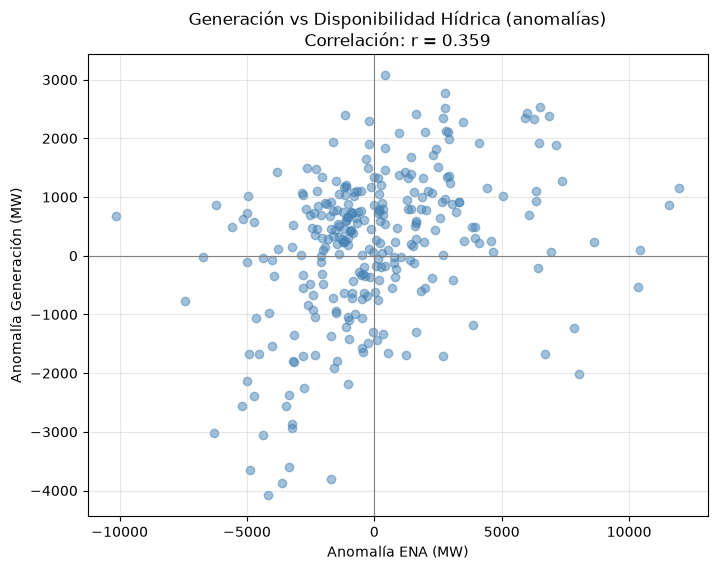

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(test_anomaly['ena_anomaly'], test_anomaly['gen_anomaly'], alpha=0.5, color='steelblue')
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel('Anomalía ENA (MW)')
plt.ylabel('Anomalía Generación (MW)')
plt.title(f'Generación vs Disponibilidad Hídrica (anomalías)\nCorrelación: r = {corr_anomaly:.3f}')
plt.grid(alpha=0.3)
plt.show()

## Conclusiones

- La correlación entre generación de Itaipú y disponibilidad hídrica real (ENA) es moderada (r = 0.36), incluso después de remover el efecto estacional.
- La relación es ligeramente más fuerte con 1 mes de retraso, sugiriendo un breve tiempo de respuesta entre la hidrología de la cuenca y el impacto en generación.
- La lluvia puntual de una sola estación (Encarnación, r ≈ 0.25) y el índice ONI (El Niño/La Niña, r ≈ 0.00-0.03) son predictores mucho más débiles — la Itaipú depende de la hidrología de una cuenca extensa y regional (sur de Brasil), no de eventos climáticos localizados o globales aislados.
- La sequía de 2020-2022 fue el evento más severo del período analizado, con caída de generación de ~13.000 MW a menos de 7.000 MW.